In [1]:
#enter paths to other dependent folders
MachInterp_path = '/grid/klindt/home/issa/0_SuperPosition-Paper/MachInterp'
VisPopCode_path = '/grid/klindt/home/issa/VisPopCode'

%load_ext autoreload
%autoreload 2

import sys

sys.path.append(MachInterp_path)
import mis
import odd_one_out
import cross_mis
import metric

import data
from data import loadData

import similarities
from similarities import loadMetrics

sys.path.append(VisPopCode_path)

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
import wandb
import os


# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
identifier='Vinken2023'
region='IT'
images, activations=loadData(identifier,region)

activations = torch.tensor(activations, dtype=torch.float32, device=device)
activations -= torch.mean(activations)
activations /= torch.std(activations)

images.shape, activations.shape

/tmp/ipykernel_577653/546277935.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  activations = torch.tensor(activations, dtype=torch.float32, device=device)


(torch.Size([1379, 3, 224, 224]), torch.Size([1379, 449]))

In [3]:
class SAE(torch.nn.Module):
    def __init__(self, num_input=1024, num_latent=2048):
        super().__init__()
        self.encoder = torch.nn.Linear(num_input, num_latent, bias=True)
        self.decoder = torch.nn.Linear(num_latent, num_input, bias=True)
        
    def forward(self, x):
        z = torch.relu(self.encoder(x))
        rec = self.decoder(z)
        return z, rec
    
sae = SAE(449, 449).to(device)
path=f'/grid/klindt/home/issa/0_Superposition-Paper/PopCode/results/ckpts/{identifier}_{region}/'
files = os.listdir(path)
ind_sort = np.argsort([float(_.split('_')[1]) for _ in files])
files = [files[i] for i in ind_sort]

# Take pretty sparse SAE that scored high
f = files[-1]
print(f)

z_sae = torch.load(os.path.join(path,f,'best_latent.pt')).numpy()
z_sae.shape

lambda_1.0000e+01


/tmp/ipykernel_577653/54894690.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  z_sae = torch.load(os.path.join(path,f,'best_latent.pt')).numpy()


(1379, 449)

In [4]:
import sklearn
from sklearn.cluster import MiniBatchKMeans

# fit on the whole data
kmeans = MiniBatchKMeans(
    n_clusters=activations.shape[1],
    random_state=42,
    #batch_size=256,
    #max_iter=10,
    #n_init="auto"
).fit(activations)

z_k = -kmeans.transform(activations)
z_k.shape

(1379, 449)

In [5]:
# Xmis takes a while, so just do the first 10 neurons for demo
codes = {
    'neurons': activations[:, :10],
    'sae': z_sae[:, :10],
    'k-means': z_k[:, :10],
}

In [6]:
# load precomputed similarity_matricies
sim_metrics = ['dreamsim','lpips']
all_metrics=loadMetrics(sim_metrics=sim_metrics, identifier=identifier, region=region, images=images)
dreamsim = all_metrics['dreamsim']
lpips = all_metrics['lpips']

dreamsim embeddings found in shared folder
(1379, 1379)
lpips embeddings found in shared folder
(1379, 1379, 6)


In [7]:
# MIS
result_mis = {}
for key, code in codes.items():
    if isinstance(code, torch.Tensor):
        code = code.detach().cpu().numpy()
    else:
        code = code
    print('computing', key)
    result_mis[key] = mis.compute_score(
        inputs=images,
        activations=code,
        metrics={'dreamsim': dreamsim},
    )

for k, v in result_mis[key].items():
    print(k, v.shape)

computing neurons


100%|██████████| 10/10 [00:00<00:00, 35.65it/s]


computing sae


100%|██████████| 10/10 [00:00<00:00, 36.51it/s]


computing k-means


100%|██████████| 10/10 [00:00<00:00, 35.22it/s]

quantiles (6,)
logits_dreamsim (10, 6, 50, 2, 2)
accuracy_dreamsim (10, 6)


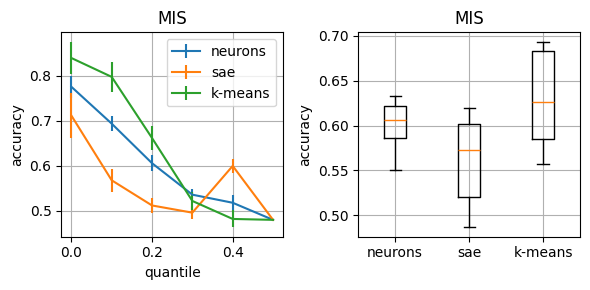

In [8]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
for key, result in result_mis.items():
    plt.errorbar(
        result['quantiles'],
        result['accuracy_dreamsim'].mean(0),
        result['accuracy_dreamsim'].std(0) / np.sqrt(result['accuracy_dreamsim'].shape[0]),
        label=key,
    )
plt.legend()
plt.grid()
plt.xlabel('quantile')
plt.ylabel('accuracy')
plt.title('MIS')

plt.subplot(1, 2, 2)
plt.boxplot(
    [result['accuracy_dreamsim'].mean(1) for result in result_mis.values()]
)
plt.xticks(
    np.arange(1, len(codes) + 1),
    list(codes.keys())
)
plt.grid()
plt.ylabel('accuracy')
plt.title('MIS')
plt.tight_layout()
plt.show()

In [9]:
# Odd one out
result_ooo = {}
for key, code in codes.items():
    if isinstance(code, torch.Tensor):
        code = code.detach().cpu().numpy()
    else:
        code = code
    print('computing', key)
    result_ooo[key] = odd_one_out.compute_score(
        inputs=images,
        activations=code,
        metrics={'dreamsim': dreamsim},
    )

for k, v in result_ooo[key].items():
    print(k, v.shape)

computing neurons


100%|██████████| 10/10 [00:00<00:00, 615.48it/s]


computing sae


100%|██████████| 10/10 [00:00<00:00, 826.53it/s]


computing k-means


100%|██████████| 10/10 [00:00<00:00, 828.91it/s]

ks (5,)
accuracy_dreamsim (10, 5)


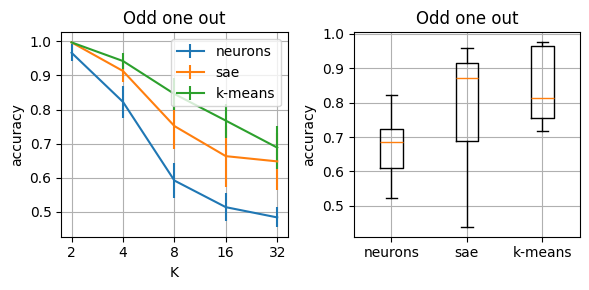

In [10]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
for key, result in result_ooo.items():
    plt.errorbar(
        np.log2(result['ks']),
        result['accuracy_dreamsim'].mean(0),
        result['accuracy_dreamsim'].std(0) / np.sqrt(result['accuracy_dreamsim'].shape[0]),
        label=key,
    )
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('accuracy')
plt.title('Odd one out')
plt.xticks(np.log2(result['ks']), result['ks'])

plt.subplot(1, 2, 2)
plt.boxplot(
    [result['accuracy_dreamsim'].mean(1) for result in result_ooo.values()]
)
plt.xticks(
    np.arange(1, len(codes) + 1),
    list(codes.keys())
)
plt.grid()
plt.ylabel('accuracy')
plt.title('Odd one out')
plt.tight_layout()
plt.show()

In [11]:
# Cross MIS
result_cross = {}
for key, code in codes.items():
    print('computing', key)
    result_cross[key] = cross_mis.compute_score(
        inputs=images,
        activations=code,
        metrics={'dreamsim': dreamsim},
    )

for k, v in result_cross[key].items():
    print(k, v.shape)

computing neurons


100%|██████████| 10/10 [00:00<00:00, 36.04it/s]


computing sae


100%|██████████| 10/10 [00:00<00:00, 36.85it/s]


computing k-means


100%|██████████| 10/10 [00:00<00:00, 36.16it/s]

accuracy_dreamsim (10, 10, 9)
ks (9,)


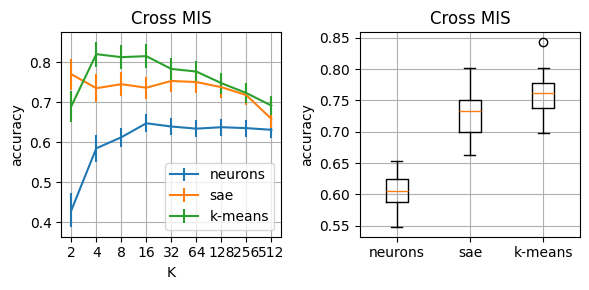

In [12]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
for key, result in result_cross.items():
    plt.errorbar(
        np.log2(result['ks']),
        result['accuracy_dreamsim'].mean((0, 1)),
        result['accuracy_dreamsim'].std((0, 1)) / result['accuracy_dreamsim'].shape[0],
        label=key,
    )
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('accuracy')
plt.title('Cross MIS')
plt.xticks(np.log2(result['ks']), result['ks'])

plt.subplot(1, 2, 2)
plt.boxplot(
    [result['accuracy_dreamsim'].mean((1, 2)) for result in result_cross.values()]
)
plt.xticks(
    np.arange(1, len(codes) + 1),
    list(codes.keys())
)
plt.grid()
plt.ylabel('accuracy')
plt.title('Cross MIS')
plt.tight_layout()
plt.show()

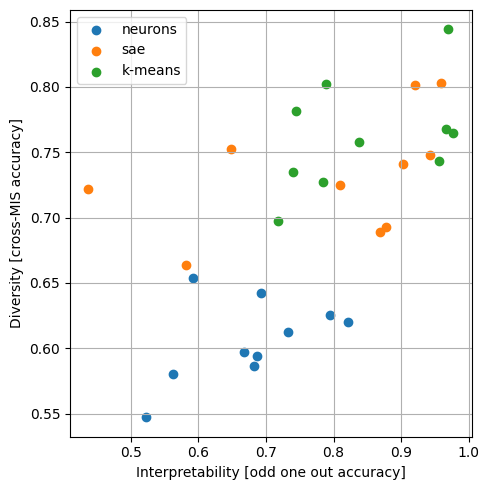

In [13]:
plt.figure(figsize=(5, 5))
for key in codes:
    plt.scatter(
        result_ooo[key]['accuracy_dreamsim'].mean(1)[:10],
        result_cross[key]['accuracy_dreamsim'].mean((1, 2)),
        label=key
    )
plt.legend()
plt.xlabel('Interpretability [odd one out accuracy]')
plt.ylabel('Diversity [cross-MIS accuracy]')
plt.grid()
plt.tight_layout()
plt.show()